<a href="https://colab.research.google.com/github/Benjamin-liao/DOE_Python_Regression/blob/main/DOE_Python_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

lib success
    infill_density  wall_thickness structure material  yield_strength
0               20             0.4       TRI      PLA             7.4
1              100             1.6       TRI      PLA            15.7
2               60             0.4       TRI      ABS             4.5
3              100             0.4       TRI      ABS             7.7
4               20             1.6       TRI      ABS             8.5
5               20             1.6       REC      PLA            13.9
6               60             1.0       TRI      PLA            10.1
7              100             0.4       REC      PLA            11.6
8               60             1.6       REC      ABS             9.1
9               20             0.4       REC      ABS             3.9
10              60             1.0       REC      PLA            10.2
11             100             1.6       REC      ABS            10.1
;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
                

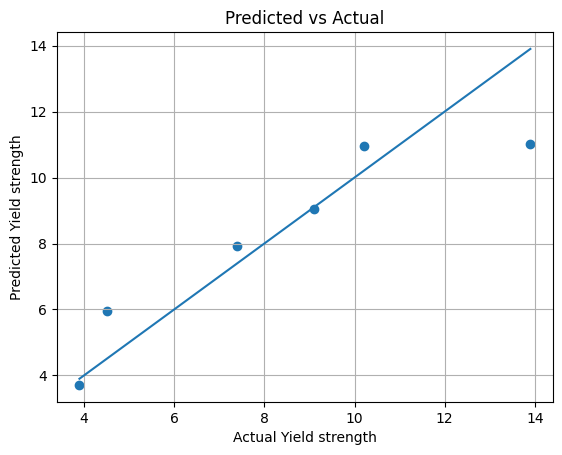

MSE: 1.89
R²: 0.84


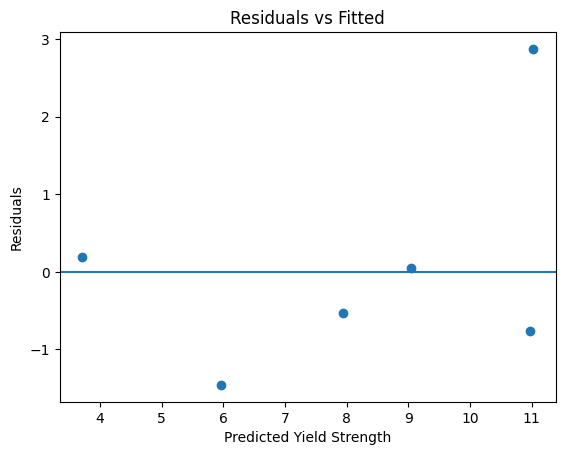

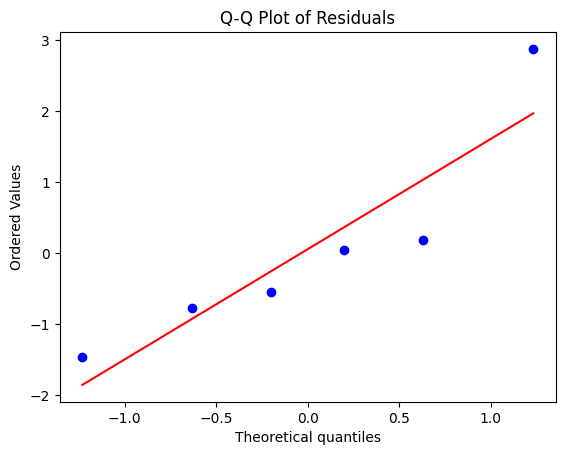

Train R²: 0.9062383766582633
Test R²: 0.8386432197572976


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels.api as sm

print("lib success")

'''-----------------------------------------------------------------------------
#phase_00
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 10

x = np.linspace(0, 10, 50)
y = 2.5 * x + np.random.normal(0, 2, size=len(x))

plt.scatter(x, y)
plt.plot(x, 2.5 * x)
plt.xlabel("input factor")
plt.ylabel("Response")
plt.title("Sanity Check Plot")
plt.show()
-----------------------------------------------------------------------------'''



'''-----------------------------------------------------------------------------
#phase_01
#this is a temporary input
experiment = {
    "infill_density": [20, 40, 60, 80],
    "wall_thickness": [1, 2, 3, 4],
    "material": ["PLA", "PLA", "ABS", "ABS"]
}

#this convert tamp data to actual table
df = pd.DataFrame(experiment)

df["tensile_strength"] = [22.1, 25.3, 27.8, 30.2]
df["yeild_time"] = [118, 110, 112, 108]

df[["infill_density", "wall_thickness"]]
df.iloc[:,:]

df["tensile_strength"].mean()
df["tensile_strength"].std()

df.groupby("material")["tensile_strength"].mean()

for factor in ["infill_density", "wall_thickness", "tensile_strength", "yeild_time"]:
    print(factor,":",df[factor].mean())
    #print(df[factor].mean())

print(df.iloc[:,:])

#check
plt.scatter(df["infill_density"], df["tensile_strength"])
plt.plot(df["infill_density"], 0.133*df["infill_density"]+20)
plt.xlabel("Infill Density (%)")
plt.ylabel("Tensile Strength (MPa)")
plt.title("Response vs Infill Density")
plt.show()
-----------------------------------------------------------------------------'''

'''-----------------------------------------------------------------------------
#phase_02
#import csv table from cloud
from google.colab import drive
drive.mount("/content/drive"
'''
df = pd.read_csv("/content/drive/MyDrive/Colab/csv/Spring_data_DOE_trim.csv")
print(df.iloc[:,:])


#catagization conversion
#df.info()
#df.describe()
X = df[["infill_density", "wall_thickness", "structure", "material"]]
y = df["yield_strength"]

material="PLA"
X_encoded = pd.get_dummies(X, columns=["material","structure"], drop_first=True)
X_encoded


#scaling:comparable scale in STDdev~1 form a normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

#split "train" for model fit and to validate with "test"
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.5, random_state=42
)
print(";;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;")
'''
#check
plt.scatter(df["wall_thickness"], df["yield_strength"])
plt.xlabel("Infill Density")
plt.ylabel("Yield strength")
plt.title("Response vs Infill Density")
plt.show()
'''

'''phase_03---------------------------------------------------------------------
'''

import statsmodels.formula.api as smf
#fit model
model = smf.ols(
    "yield_strength ~ wall_thickness*infill_density + wall_thickness + infill_density",
    data=df
).fit()
print(model.summary())

#ANOVA_table
import statsmodels.api as sm

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

#prediction_model
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

#define_prediction_model
y_pred = reg.predict(X_test)

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Yield strength")
plt.ylabel("Predicted Yield strength")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.show()

#validation
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")


'''
--------------------------------------------------------------------------------
#phase04
'''

#Part_A
#Validation_residual_vs_fitted
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Yield Strength")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

'''
#Valisation_normalality_0f_residual
plt.hist(residuals, bins=10)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()'''

#Validation_Q-Q_plot
import scipy.stats as stats
stats.probplot(residuals, plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

'''
#Validation_Prediction_vs_actual
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
     [y_test.min(), y_test.max()])
plt.xlabel("Actual Yield Strength")
plt.ylabel("Predicted Yield Strength")
plt.title("Predicted vs Actual")
plt.show()'''

#Validation_Training_vs_Test(R^2)
from sklearn.metrics import r2_score

train_pred = reg.predict(X_train)
test_pred = reg.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
